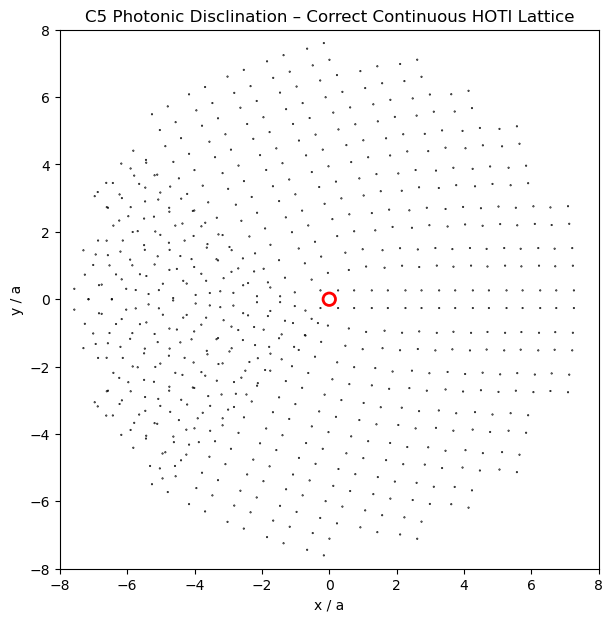

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ==============================
# PARAMETERS (FROM PAPER)
# ==============================
a = 1.0
r_hole = 0.01 * a
d = 0.37 * a / np.sqrt(2)

N = 8                  # lattice size
stretch = 5/4          # C4 -> C5
r_max = 7.5 * a

# HOTI basis (local coordinates)
basis = np.array([
    [ d,  d],
    [ d, -d],
    [-d,  d],
    [-d, -d],
])

atoms = []

# ==============================
# BUILD + DEFORM LATTICE
# ==============================
for i in range(-N, N):
    for j in range(-N, N):
        cell_center = np.array([i * a, j * a])

        r = np.linalg.norm(cell_center)
        if r > r_max:
            continue

        theta = np.arctan2(cell_center[1], cell_center[0])
        theta_new = stretch * theta

        # rotation matrix for local basis
        R = np.array([
            [np.cos(theta_new - theta), -np.sin(theta_new - theta)],
            [np.sin(theta_new - theta),  np.cos(theta_new - theta)]
        ])

        # new cell center
        new_center = r * np.array([np.cos(theta_new), np.sin(theta_new)])

        for b in basis:
            atoms.append(new_center + R @ b)

atoms = np.array(atoms)

# ==============================
# PLOT
# ==============================
fig, ax = plt.subplots(figsize=(7,7))

for (x, y) in atoms:
    ax.add_patch(Circle((x, y), r_hole, edgecolor='black', facecolor='none'))

ax.scatter(0, 0, s=80, facecolors='none', edgecolors='red', linewidths=2)

ax.set_aspect("equal")
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_xlabel("x / a")
ax.set_ylabel("y / a")
ax.set_title("C5 Photonic Disclination – Correct Continuous HOTI Lattice")
plt.show()


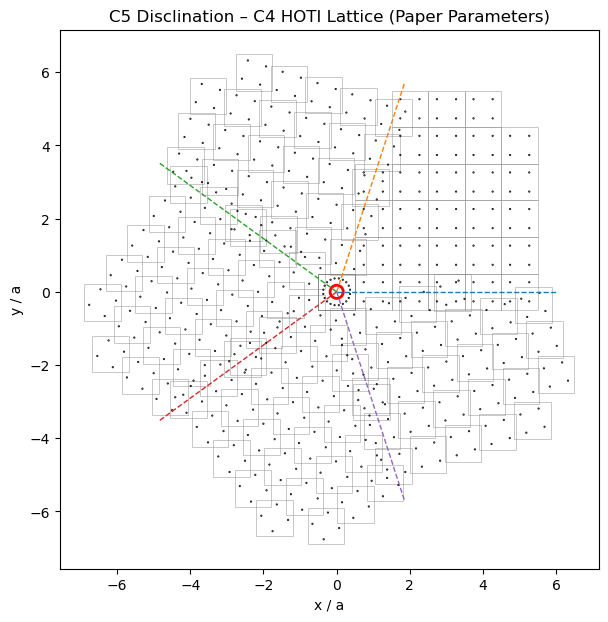

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

# ==============================
# PARAMETERS (FROM PAPER)
# ==============================
a = 1.0                     # lattice constant (normalized)
r_hole = 0.01 * a            # air-hole radius
d = 0.37 * a / np.sqrt(2)   # basis offset

N = 6                       # number of unit cells (finite)
n_sym = 5                   # C5 disclination
r_max = 7.0 * a             # cavity radius

sector_angle = 2 * np.pi / n_sym

# ==============================
# C4 HOTI BASIS (4 ATOMS)
# ==============================
basis = np.array([
    [ d,  d],
    [ d, -d],
    [-d,  d],
    [-d, -d],
])

# ==============================
# BUILD FINITE SECTOR OF C4 LATTICE
# ==============================
cells = []
atoms = []

for i in range(-N, N):
    for j in range(-N, N):
        cell_center = np.array([i * a, j * a])

        # angular selection using cell center
        r = np.linalg.norm(cell_center)
        theta = np.arctan2(cell_center[1], cell_center[0])

        if r < r_max and 0 <= theta < sector_angle:
            cells.append(cell_center)
            for b in basis:
                atoms.append(cell_center + b)

cells = np.array(cells)
atoms = np.array(atoms)

# ==============================
# ROTATE SECTOR TO FORM C5
# ==============================
all_cells = []
all_atoms = []

for k in range(n_sym):
    phi = k * sector_angle
    R = np.array([
        [np.cos(phi), -np.sin(phi)],
        [np.sin(phi),  np.cos(phi)]
    ])
    all_cells.append(cells @ R.T)
    all_atoms.append(atoms @ R.T)

all_cells = np.vstack(all_cells)
all_atoms = np.vstack(all_atoms)

# ==============================
# PLOT: UNIT CELLS + AIR HOLES
# ==============================
fig, ax = plt.subplots(figsize=(7,7))

# unit-cell boxes (centered)
for (x, y) in all_cells:
    rect = Rectangle(
        (x - a/2, y - a/2),
        a, a,
        linewidth=0.6,
        edgecolor='gray',
        facecolor='none',
        alpha=0.5
    )
    ax.add_patch(rect)

# air holes
for (x, y) in all_atoms:
    circ = Circle((x, y), r_hole, edgecolor='black', facecolor='none', linewidth=1)
    ax.add_patch(circ)

# symmetry guide lines
for k in range(n_sym):
    ang = 2*np.pi*k/n_sym
    ax.plot([0, 6*np.cos(ang)], [0, 6*np.sin(ang)], '--', lw=1)

# mark origin (must be empty)
ax.scatter(0, 0, s=90, facecolors='none', edgecolors='red', linewidths=2)

ax.set_aspect("equal")
ax.set_xlabel("x / a")
ax.set_ylabel("y / a")
ax.set_title("C5 Disclination – C4 HOTI Lattice (Paper Parameters)")
plt.show()



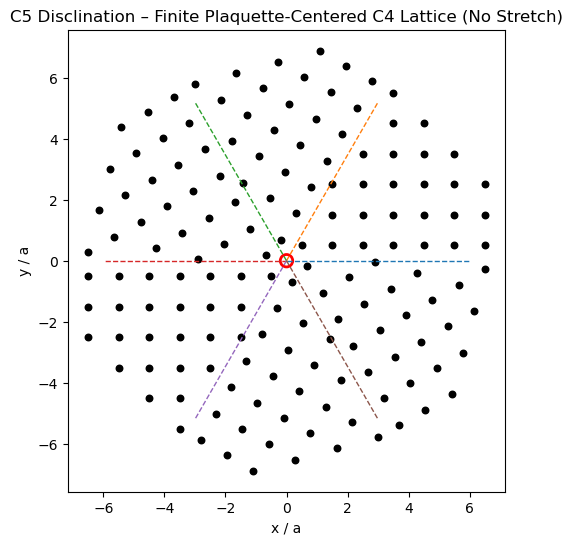

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# PARAMETERS
# ==============================
a = 1.0            # lattice constant
N = 8              # lattice half-size (controls finiteness)
n_sym = 5         # C5 disclination
r_max = 7.0 * a    # finite cavity radius

sector_angle = 2 * np.pi / n_sym

# ==============================
# BUILD PLAQUETTE-CENTERED C4 LATTICE (FINITE)
# ==============================
base_pts = []
for i in range(-N, N):
    for j in range(-N, N):
        x = (i + 0.5) * a
        y = (j + 0.5) * a
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)

        if r < r_max and 0 <= theta < sector_angle:
            base_pts.append([x, y])

base_pts = np.array(base_pts)

# ==============================
# ROTATE SECTOR TO FORM C5
# ==============================
coords = []
for k in range(n_sym):
    phi = k * sector_angle
    R = np.array([
        [np.cos(phi), -np.sin(phi)],
        [np.sin(phi),  np.cos(phi)]
    ])
    coords.append(base_pts @ R.T)

coords = np.vstack(coords)

# ==============================
# PLOT (GEOMETRY CHECK)
# ==============================
plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=22, color="black")

# symmetry guide lines
for k in range(n_sym):
    ang = 2*np.pi*k/n_sym
    plt.plot([0, 6*np.cos(ang)], [0, 6*np.sin(ang)], '--', lw=1)

# mark origin (must be empty)
plt.scatter(0, 0, s=80, facecolors='none', edgecolors='red', linewidths=2)

plt.gca().set_aspect("equal")
plt.xlabel("x / a")
plt.ylabel("y / a")
plt.title("C5 Disclination – Finite Plaquette-Centered C4 Lattice (No Stretch)")
plt.show()



Initializing eigensolver data
Computing 6 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 10 x 10 x 1.
Solving for 6 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     cylinder, center = (0.35,0.35,0)
          radius 0.2, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.35,-0.35,0)
          radius 0.2, height 1e+20, axis (0, 0, 1)
     cylinder, center = (-0.35,0.35,0)
          radius 0.2, height 1e+20, axis (0, 0, 1)
     cylinder, center = (-0.35,-0.35,0)
          radius 0.2, height 1e+20, axis (0, 0, 1)
Geometric object tree has depth 3 and 16 object nodes (vs. 4 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
64 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.023809523

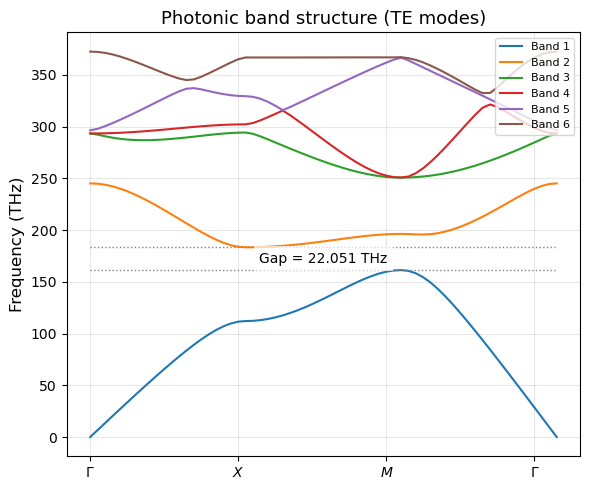

In [ ]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            import meep as mp
from meep import mpb
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Lattice and geometry
# -------------------------------------------------
a = 1
r = 0.2 * a  # hole radius
eps_bg = 3.42**2

# 4 holes at corners of square lattice
# Centers at distance 0.4a from the center
offset = 0.35 * a

geometry = [
    mp.Cylinder(
        radius=r,
        height=mp.inf,
        center=mp.Vector3(+offset, +offset),
        material=mp.Medium(epsilon=1.0)
    ),
    mp.Cylinder(
        radius=r,
        height=mp.inf,
        center=mp.Vector3(+offset, -offset),
        material=mp.Medium(epsilon=1.0)
    ),
    mp.Cylinder(
        radius=r,
        height=mp.inf,
        center=mp.Vector3(-offset, +offset),
        material=mp.Medium(epsilon=1.0)
    ),
    mp.Cylinder(
        radius=r,
        height=mp.inf,
        center=mp.Vector3(-offset, -offset),
        material=mp.Medium(epsilon=1.0)
    ),
]

lattice = mp.Lattice(size=mp.Vector3(1, 1))

resolution = 10
num_bands = 6

# -------------------------------------------------
# k-point path Γ–X–M–Γ
# -------------------------------------------------
Gamma = mp.Vector3(0, 0)
X = mp.Vector3(0.5, 0)
M = mp.Vector3(0.5, 0.5)

k_points = mp.interpolate(20, [Gamma, X, M, Gamma])

# -------------------------------------------------
# MPB solver
# -------------------------------------------------
ms = mpb.ModeSolver(
    geometry_lattice=lattice,
    geometry=geometry,
    k_points=k_points,
    resolution=resolution,
    num_bands=num_bands,
    default_material=mp.Medium(epsilon=eps_bg)
)

# -------------------------------------------------
# Run TE bands
# -------------------------------------------------
ms.run_te()

bands = np.array(ms.all_freqs)

# -------------------------------------------------
# Plot photonic band structure in THz (colored bands + gap annotation)
# -------------------------------------------------
# For THz conversion (adjust a_nm as needed for your system)
a_nm = 459.0  # lattice constant in nm
c0 = 299_792_458.0  # m/s
freq_scale_THz = (c0 / (a_nm * 1e-9)) / 1e12  # THz per normalized frequency unit
bands_THz = bands * freq_scale_THz

fig, ax = plt.subplots(figsize=(6, 5))
cmap = plt.get_cmap('tab10')
colors = [cmap(i % 10) for i in range(num_bands)]
for n in range(num_bands):
    ax.plot(bands_THz[:, n], color=colors[n], linewidth=1.5, label=f'Band {n+1}')
# Compute gap between band 1 and band 2 (indices 0 and 1)
max_band1 = bands_THz[:, 0].max()
min_band2 = bands_THz[:, 1].min()
gap_thz = min_band2 - max_band1
# Draw dotted horizontal lines at max(band1) and min(band2)
x_min = 0
x_max = bands_THz.shape[0] - 1
ax.hlines(max_band1, x_min, x_max, colors='gray', linestyles=':', linewidth=1)
ax.hlines(min_band2, x_min, x_max, colors='gray', linestyles=':', linewidth=1)
# Annotate the gap value (THz) between the two lines
mid_x = 0.5 * (x_min + x_max)
mid_y = max_band1 + 0.5 * max(0.0, gap_thz)
ax.text(mid_x, mid_y, f"Gap = {gap_thz:.3f} THz", color='black',
        fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
xticks = [0, 20, 40, 60]
xlabels = [r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$']
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_ylabel("Frequency (THz)", fontsize=12)
ax.set_title("Photonic band structure (TE modes)", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000791788 s
Working in 2D dimensions.
Computational cell is 7 x 7 x 0 with resolution 200
     cylinder, center = (-3,-3,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,-2,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,-1,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,0,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,1,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,2,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon di

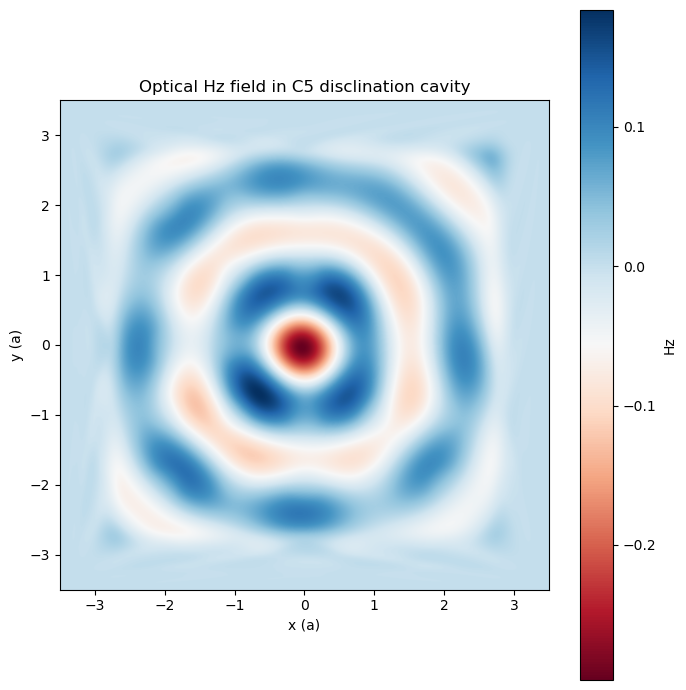

In [1]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 1.0  # lattice constant
r = 0.22 * a  # hole radius
eps_bg = 3.42**2
resolution = 200
num_bands = 6

# C4 lattice (quadrumer) parameters
lattice_size = 7  # number of sites along one direction
center = (lattice_size // 2, lattice_size // 2)

# Volterra process: remove 72° sector and glue edges to create C5 disclination
def generate_c5_disclination_lattice(a, r, lattice_size):
    geometry = []
    angle_remove = 2 * np.pi / 5  # 72 degrees
    for i in range(lattice_size):
        for j in range(lattice_size):
            # Position relative to center
            x = (i - center[0]) * a
            y = (j - center[1]) * a
            angle = np.arctan2(y, x)
            # Remove sector: skip points in the removed sector
            if angle < 0:
                angle += 2 * np.pi
            if angle < angle_remove:
                continue
            # Add cylinder (hole) at this position
            geometry.append(
                mp.Cylinder(
                    radius=r,
                    height=mp.inf,
                    center=mp.Vector3(x, y),
                    material=mp.Medium(epsilon=1.0)
                )
            )
    return geometry

geometry = generate_c5_disclination_lattice(a, r, lattice_size)

# Simulation cell large enough to contain the structure
cell_size = mp.Vector3(a * lattice_size, a * lattice_size, 0)

# Lattice (not used for MPB, but for visualization)
lattice = mp.Lattice(size=cell_size)

# Set up simulation
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=geometry,
    resolution=resolution,
    default_material=mp.Medium(epsilon=eps_bg),
    boundary_layers=[mp.PML(1.0)],
    sources=[
        mp.Source(
            mp.ContinuousSource(frequency=0.2, width=20),
            component=mp.Ez,
            center=mp.Vector3(0, 0),
            size=mp.Vector3(0, 0)
        )
    ]
)

# Run until fields have settled
sim.run(until=200)

# Get Hz field (Ez for 2D TM, Hz for 2D TE)
hz_data = sim.get_array(center=mp.Vector3(), size=cell_size, component=mp.Ez)

# Plot Hz field
plt.figure(figsize=(7, 7))
plt.imshow(np.real(hz_data).T, origin='lower', extent=[-cell_size.x/2, cell_size.x/2, -cell_size.y/2, cell_size.y/2], cmap='RdBu')
plt.colorbar(label='Hz')
plt.title('Optical Hz field in C5 disclination cavity')
plt.xlabel('x (a)')
plt.ylabel('y (a)')
plt.tight_layout()
plt.show()

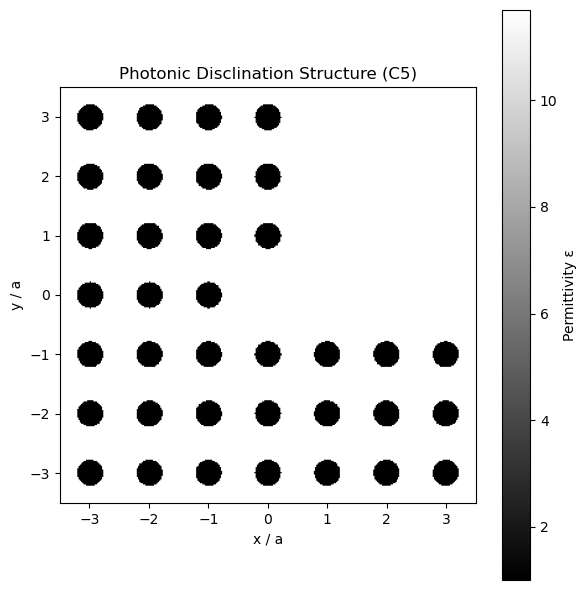

-----------
Initializing structure...
time for choose_chunkdivision = 0.000340939 s
Working in 2D dimensions.
Computational cell is 7 x 7 x 0 with resolution 48
     cylinder, center = (-3,-3,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,-2,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,-1,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,0,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,1,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3,2,0)
          radius 0.22, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon dia

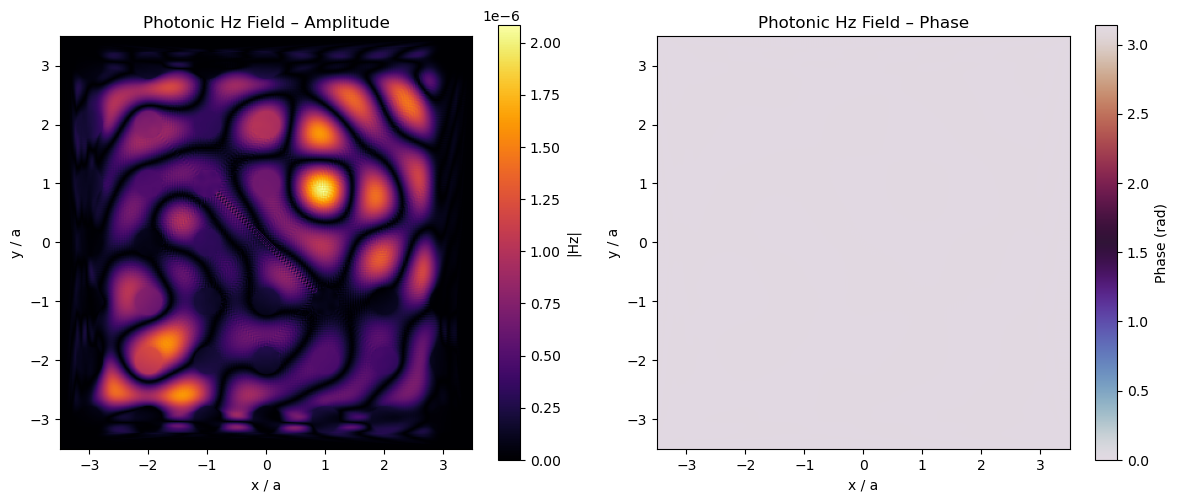

In [3]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Physical & numerical parameters
# =========================================================
a = 1.0                     # lattice constant
r = 0.22 * a                # air-hole radius
eps_bg = 3.42**2            # background permittivity
resolution = 48             # GOOD for FDTD (do NOT use 200)
lattice_size = 7            # odd number preferred
pml_thickness = 1.0

# =========================================================
# 2. Generate C5 disclination geometry (geometric cut)
# =========================================================
def generate_c5_geometry(a, r, lattice_size):
    geometry = []
    center = lattice_size // 2
    removed_angle = 2*np.pi/5  # 72 degrees

    for i in range(lattice_size):
        for j in range(lattice_size):
            x = (i - center) * a
            y = (j - center) * a

            if x == 0 and y == 0:
                continue

            phi = np.arctan2(y, x)
            if phi < 0:
                phi += 2*np.pi

            # Volterra cut (sector removal)
            if phi < removed_angle:
                continue

            geometry.append(
                mp.Cylinder(
                    radius=r,
                    height=mp.inf,
                    center=mp.Vector3(x, y),
                    material=mp.air
                )
            )
    return geometry

geometry = generate_c5_geometry(a, r, lattice_size)

# =========================================================
# 3. Simulation cell
# =========================================================
cell_size = mp.Vector3(
    lattice_size * a,
    lattice_size * a,
    0
)

# =========================================================
# 4. Plot STRUCTURE (before simulation)
# =========================================================
Nx = int(cell_size.x * resolution)
Ny = int(cell_size.y * resolution)

# Build permittivity map manually
eps_map = eps_bg * np.ones((Nx, Ny))

x_vals = np.linspace(-cell_size.x/2, cell_size.x/2, Nx)
y_vals = np.linspace(-cell_size.y/2, cell_size.y/2, Ny)

for cyl in geometry:
    cx, cy = cyl.center.x, cyl.center.y
    for ix, x in enumerate(x_vals):
        for iy, y in enumerate(y_vals):
            if (x - cx)**2 + (y - cy)**2 <= r**2:
                eps_map[ix, iy] = 1.0

plt.figure(figsize=(6, 6))
plt.imshow(
    eps_map.T,
    origin="lower",
    extent=[-cell_size.x/2, cell_size.x/2,
            -cell_size.y/2, cell_size.y/2],
    cmap="gray"
)
plt.colorbar(label="Permittivity ε")
plt.title("Photonic Disclination Structure (C5)")
plt.xlabel("x / a")
plt.ylabel("y / a")
plt.tight_layout()
plt.show()

# =========================================================
# 5. Source (TE polarization → Hz)
# =========================================================
sources = [
    mp.Source(
        mp.GaussianSource(
            frequency=0.18,
            fwidth=0.15
        ),
        component=mp.Hz,
        center=mp.Vector3(0, 0)
    )
]

# =========================================================
# 6. Simulation
# =========================================================
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=geometry,
    sources=sources,
    boundary_layers=[mp.PML(pml_thickness)],
    default_material=mp.Medium(epsilon=eps_bg),
    resolution=resolution,
    dimensions=2
)

# =========================================================
# 7. Run and extract Hz field
# =========================================================
sim.run(until=250)

hz = sim.get_array(
    center=mp.Vector3(),
    size=cell_size,
    component=mp.Hz
)

# =========================================================
# 8. Plot Hz amplitude and phase
# =========================================================
extent = [
    -cell_size.x/2, cell_size.x/2,
    -cell_size.y/2, cell_size.y/2
]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.abs(hz).T, origin="lower", extent=extent, cmap="inferno")
plt.colorbar(label="|Hz|")
plt.title("Photonic Hz Field – Amplitude")
plt.xlabel("x / a")
plt.ylabel("y / a")

plt.subplot(1, 2, 2)
plt.imshow(np.angle(hz).T, origin="lower", extent=extent, cmap="twilight")
plt.colorbar(label="Phase (rad)")
plt.title("Photonic Hz Field – Phase")
plt.xlabel("x / a")
plt.ylabel("y / a")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1. Parameters
# =====================================================
a = 1.0
r = 0.2 * a
eps_bg = 3.42**2
N = 6                 # number of unit cells per arm
resolution = 60      # plotting only

# =====================================================
# 2. Build C4 lattice sites
# =====================================================
sites = []
for i in range(-N, N+1):
    for j in range(-N, N+1):
        if i == 0 and j == 0:
            continue
        sites.append((i*a, j*a))

# =====================================================
# 3. Sector assignment (C4 → C5)
# =====================================================
def assign_sector(x, y):
    phi = np.arctan2(y, x)
    if phi < 0:
        phi += 2*np.pi
    return int(phi // (np.pi/2))  # 4 original sectors

# Sector rotation angles (insert one extra sector)
sector_angles = {
    0: 0.0,
    1: 2*np.pi/5,
    2: 4*np.pi/5,
    3: 6*np.pi/5,
    4: 8*np.pi/5
}

new_sites = []

for (x, y) in sites:
    s = assign_sector(x, y)

    # Split sector 0 into two → total 5 sectors
    if s == 0:
        # duplicate sector
        for new_s in [0, 1]:
            angle = sector_angles[new_s]
            r0 = np.hypot(x, y)
            phi0 = np.arctan2(y, x)
            new_phi = angle + phi0/2
            new_sites.append((r0*np.cos(new_phi), r0*np.sin(new_phi)))
    else:
        new_s = s + 1
        angle = sector_angles[new_s]
        r0 = np.hypot(x, y)
        phi0 = np.arctan2(y, x)
        new_phi = angle + (phi0 - s*np.pi/2)
        new_sites.append((r0*np.cos(new_phi), r0*np.sin(new_phi)))

# =====================================================
# 4. Create permittivity map
# =====================================================
cell_size = 2.5 * N * a
Nx = int(cell_size * resolution)
Ny = Nx

eps_map = eps_bg * np.ones((Nx, Ny))
x_vals = np.linspace(-cell_size/2, cell_size/2, Nx)
y_vals = np.linspace(-cell_size/2, cell_size/2, Ny)

for (cx, cy) in new_sites:
    for ix, x in enumerate(x_vals):
        for iy, y in enumerate(y_vals):
            if (x - cx)**2 + (y - cy)**2 <= r**2:
                eps_map[ix, iy] = 1.0

# =====================================================
# 5. Plot structure
# =====================================================
plt.figure(figsize=(6, 6))
plt.imshow(
    eps_map.T,
    origin="lower",
    extent=[-cell_size/2, cell_size/2,
            -cell_size/2, cell_size/2],
    cmap="gray"
)
plt.colorbar(label="Permittivity ε")
plt.title("C5 Disclination Cavity\n(C4 Cut + Sector Insertion)")
plt.xlabel("x / a")
plt.ylabel("y / a")

xs, ys = zip(*new_sites)
plt.scatter(xs, ys, s=6, c="red", alpha=0.6)

plt.tight_layout()
plt.show()import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Parameters
# ===============================
a = 1.0
r = 0.2 * a
N = 7                      # half-size of lattice
resolution = 60            # plotting only

# ===============================
# Build C4 lattice
# ===============================
sites = []
for i in range(-N, N + 1):
    for j in range(-N, N + 1):
        if i == 0 and j == 0:
            continue
        sites.append((i * a, j * a))

# ===============================
# Assign lattice-aligned C4 sectors
# ===============================
def sector_c4(x, y):
    if x >= 0 and y >= 0:
        return 0
    if x < 0 and y >= 0:
        return 1
    if x < 0 and y < 0:
        return 2
    return 3

# ===============================
# C4 → C5 sector insertion
# ===============================
theta = 2 * np.pi / 5      # 72°
sector_rotation = {
    0: 0 * theta,
    1: 1 * theta,
    2: 2 * theta,
    3: 3 * theta,
    4: 4 * theta
}

new_sites = []

for (x, y) in sites:
    s = sector_c4(x, y)

    # Insert extra sector by duplicating sector INDEX, not points
    if s == 0:
        new_s = 0
    else:
        new_s = s + 1

    angle = sector_rotation[new_s]

    r0 = np.hypot(x, y)
    phi0 = np.arctan2(y, x)

    x_new = r0 * np.cos(phi0 + angle)
    y_new = r0 * np.sin(phi0 + angle)

    new_sites.append((x_new, y_new))

# ===============================
# Remove duplicates (numerical safety)
# ===============================
unique_sites = []
tol = 1e-6
for p in new_sites:
    if not any(np.hypot(p[0]-q[0], p[1]-q[1]) < tol for q in unique_sites):
        unique_sites.append(p)

# ===============================
# Plot structure
# ===============================
xs, ys = zip(*unique_sites)

plt.figure(figsize=(6, 6))
plt.scatter(xs, ys, s=35, c="black")
plt.scatter(xs, ys, s=10, c="red")

plt.gca().set_aspect("equal")
plt.title("C5 Disclination Cavity\n(C4 Cut + Discrete Sector Insertion)")
plt.xlabel("x / a")
plt.ylabel("y / a")
plt.grid(False)
plt.tight_layout()
plt.show()



SyntaxError: invalid syntax (1802468689.py, line 100)